In [55]:
import numpy as np
from sklearn.utils import shuffle

from data_loader import get_data

In [56]:
# Match these to the names of the files you uploaded (without `.npy`)
class_names = ['bicycle', 'cactus', 'couch', 'divingboard', 'flamingo', 'mushroom', 'ocean', 'octopus', 'shark', 'sweater']

file_paths = [f"./data/full_numpy_bitmap_{cls}.npy" for cls in class_names]
file_paths[0]

X_train, y_train, X_valid, y_valid, X_test, y_test = get_data(file_paths)


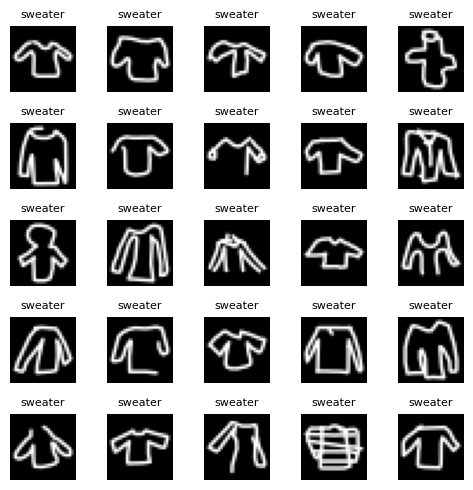

In [57]:
import matplotlib.pyplot as plt

def show_samples(X, y, classes, n=5):
    plt.figure(figsize=(n, n))
    for i in range(n * n):
        plt.subplot(n, n, i + 1)
        plt.imshow(X[90000+i][0], cmap='gray')
        plt.title(classes[y[90000+i]], fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(X_train, y_train, class_names, n=5)


In [58]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class QuickDrawCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(QuickDrawCNN, self).__init__()

        # Convolutional layer 1: 1 input channel (grayscale), 16 output channels, 3x3 kernel
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # keeps size = 28x28
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # halves to 14x14

        # Convolutional layer 2: 16 input, 32 output
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 14x14 → 14x14
        self.pool2 = nn.MaxPool2d(2, 2)  # 14x14 → 7x7

        # Fully connected layers
        self.fc1 = nn.Linear(32 * 7 * 7, 128)  # Flattened input → dense
        self.fc2 = nn.Linear(128, num_classes)  # Output layer

        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))  # (1,28,28) → (16,14,14)
        x = self.pool2(F.relu(self.conv2(x)))  # (16,14,14) → (32,7,7)
        x = x.view(-1, 32 * 7 * 7)  # Flatten for dense layer
        x = self.dropout(F.relu(self.fc1(x)))  # Dense with dropout
        x = self.fc2(x)  # No activation; will use CrossEntropyLoss
        return x





In [59]:
class QuickDrawCNN2(nn.Module):
    def __init__(self, num_classes=10):
        super(QuickDrawCNN2, self).__init__()

        # Convolutional layer 1: 1 input channel (grayscale), 32 output channels, 3x3 kernel
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)  # keeps size = 28x28
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # halves to 32x14x14

        # Convolutional layer 2: 16 input, 32 output
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 64x14x14
        self.pool2 = nn.MaxPool2d(2, 2)  # 14x14 → 64x7x7

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # Flattened input → dense
        self.fc2 = nn.Linear(128, num_classes)  # Output layer

        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))  # (1,28,28) → (16,14,14)
        x = self.pool2(F.relu(self.conv2(x)))  # (16,14,14) → (32,7,7)
        x = x.view(-1, 64 * 7 * 7)  # Flatten for dense layer
        x = self.dropout(F.relu(self.fc1(x)))  # Dense with dropout
        x = self.fc2(x)  # No activation; will use CrossEntropyLoss
        return x

In [60]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VGGLiteQuickDraw(nn.Module):
    def __init__(self, num_classes=10):
        super(VGGLiteQuickDraw, self).__init__()

        self.features = nn.Sequential(
            # Block 1: 1 → 32 → 64
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28 → 14

            # Block 2: 64 → 128 → 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 14 → 7
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.classifier(x)
        return x


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert numpy arrays to torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
X_valid_tensor = torch.tensor(X_valid, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid, dtype=torch.long)

print(X_test.shape)
print(y_test.shape)

# Create PyTorch datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)
valid_loader = DataLoader(valid_dataset, batch_size=64)

(10000, 1, 28, 28)
(10000,)


In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = QuickDrawCNN(num_classes=10).to(device)
# model = QuickDrawCNN2(num_classes=10).to(device)
# model = VGGLiteQuickDraw(num_classes=10).to(device)

criterion = torch.nn.CrossEntropyLoss()  # for multi-class classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 7  # start small

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")


Epoch 1/5, Loss: 0.5135
Epoch 2/5, Loss: 0.3072
Epoch 3/5, Loss: 0.2646
Epoch 4/5, Loss: 0.2391
Epoch 5/5, Loss: 0.2169


In [64]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        output = model(X_batch)
        preds = output.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.2%}")


Test Accuracy: 93.87%


In [65]:
# torch.save(model.state_dict(), 'quickdraw_cnn.pth') #1m 57s
# torch.save(model.state_dict(), 'quickdraw_cnn2.pth') #4m 57s


In [66]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import torch

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


In [67]:
from sklearn.metrics import classification_report

# class_names = ['cat', 'dog', 'airplane', ...]
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))


              precision    recall  f1-score   support

     bicycle     0.9595    0.9710    0.9652      1000
      cactus     0.9549    0.9310    0.9428      1000
       couch     0.9522    0.9560    0.9541      1000
 divingboard     0.8889    0.8480    0.8680      1000
    flamingo     0.9175    0.9450    0.9310      1000
    mushroom     0.9559    0.9540    0.9550      1000
       ocean     0.9286    0.9490    0.9387      1000
     octopus     0.9237    0.9570    0.9401      1000
       shark     0.9448    0.9240    0.9343      1000
     sweater     0.9606    0.9520    0.9563      1000

    accuracy                         0.9387     10000
   macro avg     0.9387    0.9387    0.9385     10000
weighted avg     0.9387    0.9387    0.9385     10000



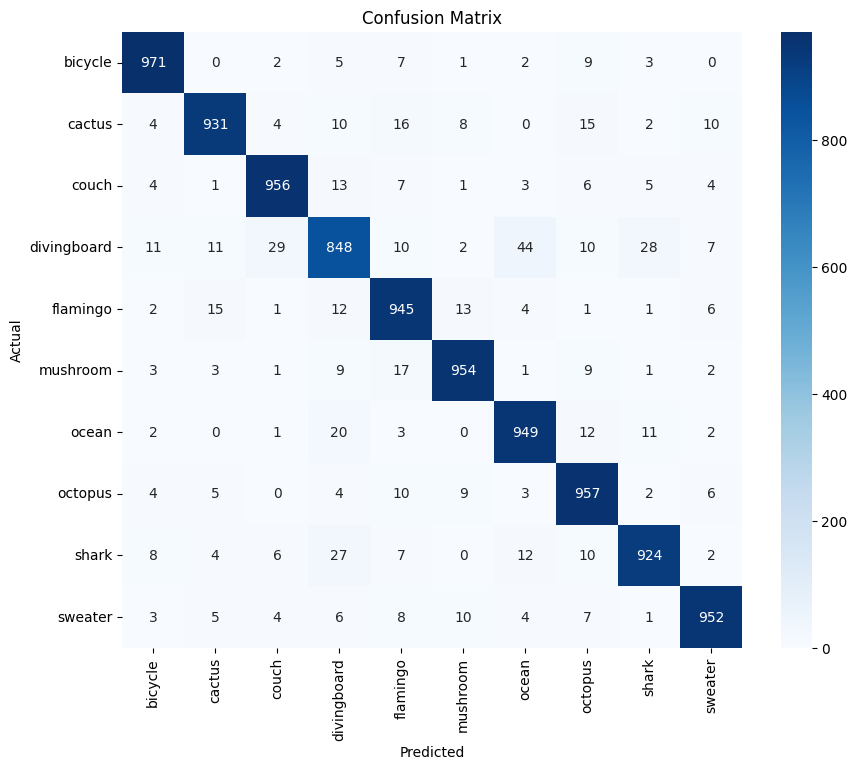

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


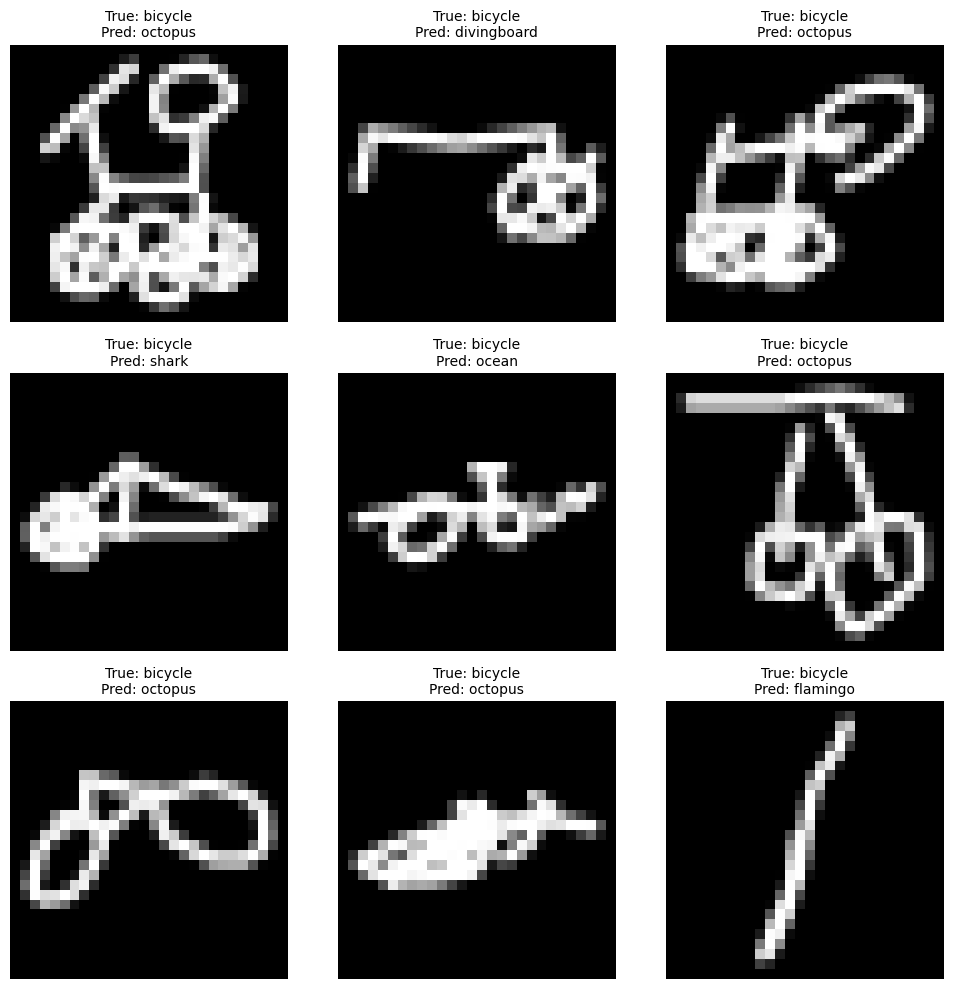

In [69]:
misclassified_idxs = np.where(all_preds != all_labels)[0]

# Visualize first N misclassified
N = 9
plt.figure(figsize=(10, 10))
for i, idx in enumerate(misclassified_idxs[:N]):
    img = X_test[idx][0]  # remove channel dim if needed
    true_label = class_names[all_labels[idx]]
    pred_label = class_names[all_preds[idx]]
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [70]:
topk_correct = 0
total = 0

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        outputs = model(X_batch)
        # Get top-2 predicted class indices
        top2_preds = torch.topk(outputs, k=2, dim=1).indices  # shape: (batch_size, 2)

        # Check if the true label is in the top 2 predictions
        for i in range(len(y_batch)):
            if y_batch[i] in top2_preds[i]:
                topk_correct += 1
        total += y_batch.size(0)

top2_accuracy = topk_correct / total
print(f"Top-2 Accuracy: {top2_accuracy:.2%}")


Top-2 Accuracy: 97.22%


In [ ]:
from tqdm import tqdm
import torch

def train_with_validation(model, train_loader, valid_loader, optimizer, criterion, device, epochs=5, save_best=False):
    model.to(device)
    best_val_acc = 0.0

    # Track history for plotting
    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        # ----- TRAIN -----
        model.train()
        total_loss = 0
        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)

        for X_batch, y_batch in train_loop:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            train_loop.set_postfix(loss=loss.item())

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ----- VALIDATE -----
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        val_loop = tqdm(valid_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)

        with torch.no_grad():
            for X_val, y_val in val_loop:
                X_val, y_val = X_val.to(device), y_val.to(device)
                output = model(X_val)
                loss = criterion(output, y_val)
                valid_loss += loss.item()

                preds = output.argmax(dim=1)
                correct += (preds == y_val).sum().item()
                total += y_val.size(0)

                val_loop.set_postfix(loss=loss.item())

        avg_valid_loss = valid_loss / len(valid_loader)
        val_accuracy = correct / total

        val_losses.append(avg_valid_loss)
        val_accuracies.append(val_accuracy)

        print(f"\nEpoch {epoch+1}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_valid_loss:.4f} | "
              f"Val Acc: {val_accuracy:.2%}")

        # Save best model if requested
        if save_best and val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            torch.save(model.state_dict(), 'best_model.pth')
            print("📦 Best model saved!")

    print("✅ Training complete.")
    return train_losses, val_losses, val_accuracies

train_losses, val_losses, val_accuracies = train_with_validation(model, train_loader, valid_loader, optimizer, criterion, device, epochs=5, save_best=False)